In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 4)

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Day16_Student_Wellbeing_Survey.csv")

print("Shape:", df.shape)
df.head()

Saving Day16_Student_Wellbeing_Survey.csv to Day16_Student_Wellbeing_Survey.csv
Shape: (600, 20)


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.2,5.7,3.2,3,11.8,5.4,63.1,3.2,5131.0,7.8
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.6,7.7,3.5,4,20.3,2.1,74.2,3.8,3508.0,9.2
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.9,6.4,2.8,1,15.0,5.2,77.3,4.0,4584.0,7.7
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.5,6.7,3.0,5,12.1,4.7,67.0,4.0,5456.0,5.3
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.4,7.3,3.0,1,30.2,5.4,65.6,3.2,11732.0,15.9


In [2]:
df.info()

df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    object 
 1   Age                             600 non-null    int64  
 2   Faculty                         600 non-null    object 
 3   Year_of_Study                   600 non-null    int64  
 4   City                            600 non-null    object 
 5   Accommodation                   600 non-null    object 
 6   Scholarship                     600 non-null    object 
 7   Part_Time_Job                   600 non-null    object 
 8   Internet_Quality                600 non-null    object 
 9   Preferred_Study_Space           600 non-null    object 
 10  Weekly_Study_Hours              600 non-null    float64
 11  Average_Sleep_Hours             600 non-null    float64
 12  Daily_Screen_Time_Hours         600 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,600,600,STU0600,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,600.0,NaN,NaN,NaN,20.763333,1.705531,17.0,20.0,21.0,22.0,25.0
Faculty,600,5,Engineering,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Study,600.0,NaN,NaN,NaN,2.388333,1.089116,1.0,1.0,2.0,3.0,4.0
City,600,8,Delhi,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accommodation,600,4,Home,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,600,2,No,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Part_Time_Job,600,2,No,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Quality,600,4,Good,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preferred_Study_Space,600,4,Home,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Student_ID                        0
Age                               0
Faculty                           0
Year_of_Study                     0
City                              0
Accommodation                     0
Scholarship                       0
Part_Time_Job                     0
Internet_Quality                  0
Preferred_Study_Space             0
Weekly_Study_Hours                0
Average_Sleep_Hours               0
Daily_Screen_Time_Hours           0
Exercise_Days_Per_Week            0
Commute_Time_Minutes              0
Stress_Score                      0
Academic_Readiness_Score          0
Overall_Satisfaction              0
Monthly_Discretionary_Spending    0
Social_Activity_Hours_Per_Week    0
dtype: int64


In [4]:
vars_central = ['Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours',
                'Stress_Score', 'Academic_Readiness_Score']

central_tendency = pd.DataFrame({
    'Mean':   df[vars_central].mean(),
    'Median': df[vars_central].median(),
    'Mode':   [df[v].mode().iloc[0] for v in vars_central]
})
central_tendency

,Mean,Median,Mode
Weekly_Study_Hours,15.691000,15.40,13.1
Average_Sleep_Hours,6.997500,7.00,7.0
Daily_Screen_Time_Hours,4.503000,4.20,3.5
Stress_Score,4.464500,4.50,4.7
Academic_Readiness_Score,71.773167,71.65,71.1


In [5]:
dispersion = pd.DataFrame({
    'Range':    df[vars_central].max() - df[vars_central].min(),
    'Variance': df[vars_central].var(ddof=1),
    'StdDev':   df[vars_central].std(ddof=1),
    'Q1':       df[vars_central].quantile(0.25),
    'Q3':       df[vars_central].quantile(0.75),
})
dispersion['IQR'] = dispersion['Q3'] - dispersion['Q1']
dispersion

,Range,Variance,StdDev,Q1,Q3,IQR
Weekly_Study_Hours,30.0,19.217047,4.383725,13.000,18.425,5.425
Average_Sleep_Hours,5.0,0.703383,0.838679,6.475,7.600,1.125
Daily_Screen_Time_Hours,11.2,3.469006,1.862527,3.200,5.400,2.200
Stress_Score,8.4,2.782494,1.668081,3.300,5.700,2.400
Academic_Readiness_Score,56.1,93.981967,9.694430,65.200,78.025,12.825


In [6]:
most_variable_std = dispersion['StdDev'].idxmax()
most_variable_cv = (dispersion['StdDev'] / df[vars_central].mean()).idxmax()

print(f"Variable with greatest variability (by raw Standard Deviation): {most_variable_std}")
print(f"Variable with greatest variability (by Coefficient of Variation, std/mean): {most_variable_cv}")

cv_table = (dispersion['StdDev'] / df[vars_central].mean()).sort_values(ascending=False)
print("\nCoefficient of Variation (relative variability), highest to lowest:")
print(cv_table)

Variable with greatest variability (by raw Standard Deviation): Academic_Readiness_Score
Variable with greatest variability (by Coefficient of Variation, std/mean): Daily_Screen_Time_Hours

Coefficient of Variation (relative variability), highest to lowest:
Daily_Screen_Time_Hours     0.413619
Stress_Score                0.373632
Weekly_Study_Hours          0.279378
Academic_Readiness_Score    0.135070
Average_Sleep_Hours         0.119854
dtype: float64


In [7]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

outlier_vars = ['Weekly_Study_Hours', 'Daily_Screen_Time_Hours',
                'Commute_Time_Minutes', 'Monthly_Discretionary_Spending']

outlier_summary = []
outlier_masks = {}
for v in outlier_vars:
    mask, lower, upper = iqr_outliers(df[v])
    outlier_masks[v] = mask
    outlier_summary.append({
        'Variable': v, 'Lower_Bound': round(lower, 2), 'Upper_Bound': round(upper, 2),
        'Num_Outliers': mask.sum(), 'Pct_Outliers': round(100 * mask.mean(), 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Variable,Lower_Bound,Upper_Bound,Num_Outliers,Pct_Outliers
0,Weekly_Study_Hours,4.86,26.56,8,1.33
1,Daily_Screen_Time_Hours,-0.10,8.70,18,3.00
2,Commute_Time_Minutes,-13.85,58.75,4,0.67
3,Monthly_Discretionary_Spending,-1430.25,13351.75,20,3.33


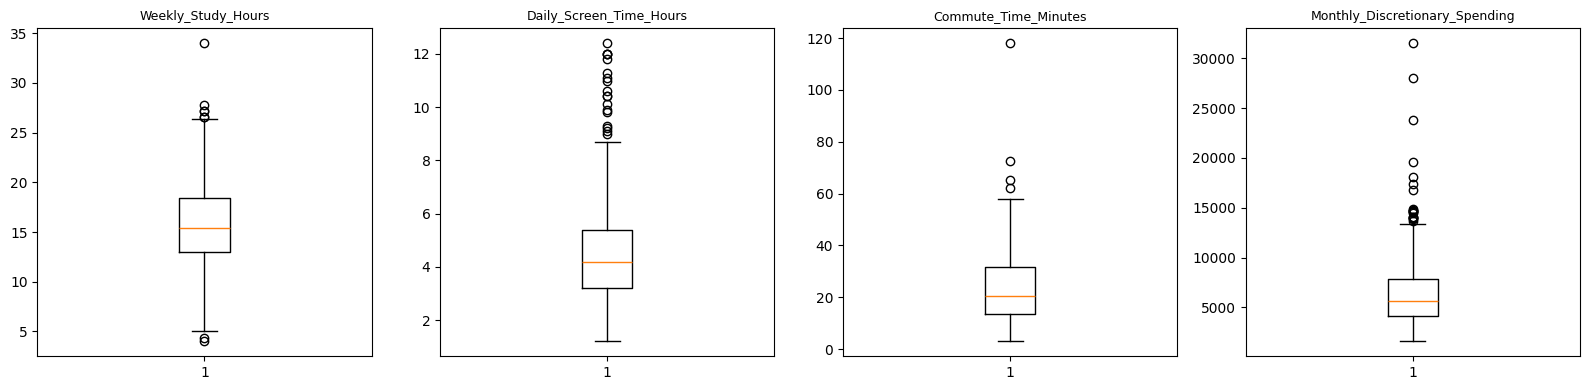

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, v in zip(axes, outlier_vars):
    ax.boxplot(df[v].dropna(), vert=True)
    ax.set_title(v, fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
target_var = 'Monthly_Discretionary_Spending'
mask = outlier_masks[target_var]

before_mean, before_median = df[target_var].mean(), df[target_var].median()
after_mean, after_median = df.loc[~mask, target_var].mean(), df.loc[~mask, target_var].median()

comparison = pd.DataFrame({
    'Before Removal': [before_mean, before_median],
    'After Removal':  [after_mean, after_median]
}, index=['Mean', 'Median'])
comparison['Difference'] = comparison['Before Removal'] - comparison['After Removal']
comparison

,Before Removal,After Removal,Difference
Mean,6343.778333,5973.718966,370.059368
Median,5685.500000,5590.500000,95.000000


In [10]:
n = len(df)

A = df['Part_Time_Job'] == 'Yes'
B = df['Stress_Score'] >= 7
C = df['Scholarship'] == 'Yes'
D = df['Exercise_Days_Per_Week'] >= 3

P_A = A.mean()
P_B = B.mean()
P_C = C.mean()
P_D = D.mean()

print(f"P(A) = P(Part_Time_Job = Yes)        = {P_A:.4f}")
print(f"P(B) = P(Stress_Score >= 7)          = {P_B:.4f}")
print(f"P(C) = P(Scholarship = Yes)          = {P_C:.4f}")
print(f"P(D) = P(Exercise_Days_Per_Week >=3) = {P_D:.4f}")

P(A) = P(Part_Time_Job = Yes)        = 0.2533
P(B) = P(Stress_Score >= 7)          = 0.0750
P(C) = P(Scholarship = Yes)          = 0.3067
P(D) = P(Exercise_Days_Per_Week >=3) = 0.5933


In [12]:
P_A_and_B = (A & B).mean()
P_A_or_B = P_A + P_B - P_A_and_B

print(f"P(A and B) = {P_A_and_B:.4f}")
print(f"P(A or B)  = P(A) + P(B) - P(A and B) = {P_A:.4f} + {P_B:.4f} - {P_A_and_B:.4f} = {P_A_or_B:.4f}")

P(A and B) = 0.0517
P(A or B)  = P(A) + P(B) - P(A and B) = 0.2533 + 0.0750 - 0.0517 = 0.2767


In [13]:
P_A_given_B = P_A_and_B / P_B
P_B_given_A = P_A_and_B / P_A

print(f"P(A|B) = P(A and B) / P(B) = {P_A_and_B:.4f} / {P_B:.4f} = {P_A_given_B:.4f}")
print(f"P(B|A) = P(A and B) / P(A) = {P_A_and_B:.4f} / {P_A:.4f} = {P_B_given_A:.4f}")

P(A|B) = P(A and B) / P(B) = 0.0517 / 0.0750 = 0.6889
P(B|A) = P(A and B) / P(A) = 0.0517 / 0.2533 = 0.2039


In [14]:
Y1 = df['Year_of_Study'] == 1
Y4 = df['Year_of_Study'] == 4

both_Y1_Y4 = (Y1 & Y4).sum()
print(f"Number of students with Year_of_Study = 1 AND Year_of_Study = 4 simultaneously: {both_Y1_Y4}")
print("Mutually exclusive?" , "YES" if both_Y1_Y4 == 0 else "NO")

Number of students with Year_of_Study = 1 AND Year_of_Study = 4 simultaneously: 0
Mutually exclusive? YES


In [15]:
P_A_times_P_B = P_A * P_B

print(f"P(A and B)   = {P_A_and_B:.4f}")
print(f"P(A) x P(B)  = {P_A:.4f} x {P_B:.4f} = {P_A_times_P_B:.4f}")
print(f"Difference   = {abs(P_A_and_B - P_A_times_P_B):.4f}")

if abs(P_A_and_B - P_A_times_P_B) < 0.01:
    print("\nConclusion: P(A and B) is approximately equal to P(A) x P(B) -> A and B APPEAR INDEPENDENT.")
else:
    print("\nConclusion: P(A and B) differs from P(A) x P(B) -> A and B are NOT independent (dependent).")

P(A and B)   = 0.0517
P(A) x P(B)  = 0.2533 x 0.0750 = 0.0190
Difference   = 0.0327

Conclusion: P(A and B) differs from P(A) x P(B) -> A and B are NOT independent (dependent).


In [16]:
P_not_A = 1 - P_A
P_B_given_notA = (B & ~A).sum() / (~A).sum()   # P(B | not A)

numerator = P_B_given_A * P_A
denominator = (P_B_given_A * P_A) + (P_B_given_notA * P_not_A)
P_A_given_B_bayes = numerator / denominator

print(f"P(A)             = {P_A:.4f}")
print(f"P(not A)          = {P_not_A:.4f}")
print(f"P(B|A)            = {P_B_given_A:.4f}")
print(f"P(B|not A)        = {P_B_given_notA:.4f}")
print()
print(f"P(A|B) via Bayes  = [P(B|A) x P(A)] / [P(B|A) x P(A) + P(B|not A) x P(not A)]")
print(f"                  = [{P_B_given_A:.4f} x {P_A:.4f}] / [{P_B_given_A:.4f} x {P_A:.4f} + {P_B_given_notA:.4f} x {P_not_A:.4f}]")
print(f"                  = {P_A_given_B_bayes:.4f}")
print()
print(f"P(A|B) via direct calculation (from Section 5) = {P_A_given_B:.4f}")
print(f"Match: {np.isclose(P_A_given_B_bayes, P_A_given_B)}")

P(A)             = 0.2533
P(not A)          = 0.7467
P(B|A)            = 0.2039
P(B|not A)        = 0.0312

P(A|B) via Bayes  = [P(B|A) x P(A)] / [P(B|A) x P(A) + P(B|not A) x P(not A)]
                  = [0.2039 x 0.2533] / [0.2039 x 0.2533 + 0.0312 x 0.7467]
                  = 0.6889

P(A|B) via direct calculation (from Section 5) = 0.6889
Match: True


In [17]:
ars = df['Academic_Readiness_Score']
mu = ars.mean()
sigma = ars.std(ddof=1)

print(f"Mean (mu)              = {mu:.4f}")
print(f"Standard Deviation (sigma) = {sigma:.4f}")

Mean (mu)              = 71.7732
Standard Deviation (sigma) = 9.6944


In [18]:
max_score = ars.max()
min_score = ars.min()

z_max = (max_score - mu) / sigma
z_min = (min_score - mu) / sigma

max_student = df.loc[ars.idxmax(), 'Student_ID']
min_student = df.loc[ars.idxmin(), 'Student_ID']

print(f"Highest score: {max_score} ({max_student})  ->  Z = ({max_score} - {mu:.2f}) / {sigma:.2f} = {z_max:.3f}")
print(f"Lowest score:  {min_score} ({min_student})  ->  Z = ({min_score} - {mu:.2f}) / {sigma:.2f} = {z_min:.3f}")

Highest score: 98.0 (STU0131)  ->  Z = (98.0 - 71.77) / 9.69 = 2.705
Lowest score:  41.9 (STU0543)  ->  Z = (41.9 - 71.77) / 9.69 = -3.081


In [19]:
for k in [1, 2, 3]:
    lower, upper = mu - k*sigma, mu + k*sigma
    actual_pct = df['Academic_Readiness_Score'].between(lower, upper).mean() * 100
    expected_pct = {1: 68, 2: 95, 3: 99.7}[k]
    print(f"Within {k} sigma [{lower:.2f}, {upper:.2f}]: "
          f"Expected ~{expected_pct}% | Actual in data = {actual_pct:.2f}%")

Within 1 sigma [62.08, 81.47]: Expected ~68% | Actual in data = 69.50%
Within 2 sigma [52.38, 91.16]: Expected ~95% | Actual in data = 95.17%
Within 3 sigma [42.69, 100.86]: Expected ~99.7% | Actual in data = 99.83%


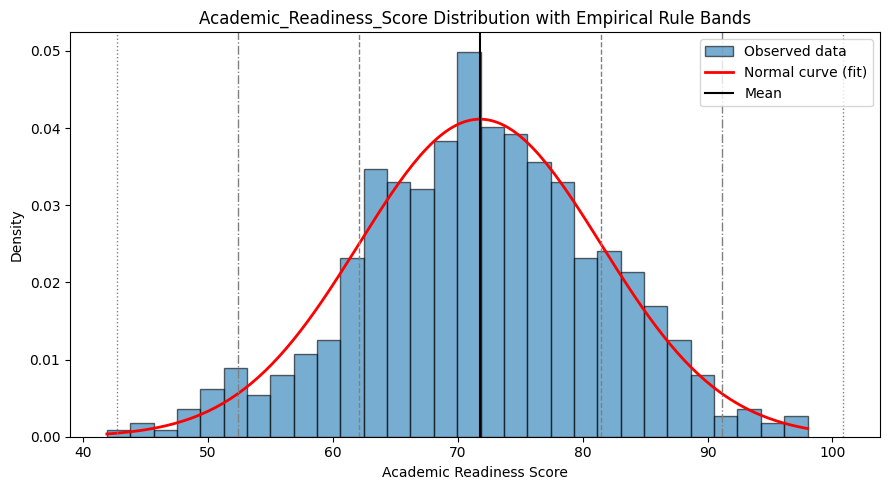

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ars, bins=30, density=True, alpha=0.6, edgecolor='black', label='Observed data')

x = np.linspace(ars.min(), ars.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal curve (fit)')

for k, ls in zip([1, 2, 3], ['--', '-.', ':']):
    ax.axvline(mu + k*sigma, color='gray', linestyle=ls, linewidth=1)
    ax.axvline(mu - k*sigma, color='gray', linestyle=ls, linewidth=1)

ax.axvline(mu, color='black', linewidth=1.5, label='Mean')
ax.set_title('Academic_Readiness_Score Distribution with Empirical Rule Bands')
ax.set_xlabel('Academic Readiness Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()